In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text


c:\Users\ianxf\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ianxf\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#df = pd.read_csv("usa_00003.csv.gz")
#df.to_pickle("data.pkl")

In [ ]:
data = pd.read_pickle("data.pkl")
print("Dimensions before filtering:", data.shape)


# CHATgpt was used to create the degfield_map from the information file included with the dataset
degfield_map = pd.DataFrame({
    "DEGFIELD": [
        0, 11, 13, 14, 15, 19, 20, 21, 22, 23, 24, 25, 26, 29,
        32, 33, 34, 35, 36, 37, 38, 40, 41, 48, 49, 50, 51, 52,
        53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64
    ],
    "FIELD_NAME": [
        "N/A",
        "Agriculture",
        "Environment and Natural Resources",
        "Architecture",
        "Area, Ethnic, and Civilization Studies",
        "Communications",
        "Communication Technologies",
        "Computer and Information Sciences",
        "Cosmetology Services and Culinary Arts",
        "Education Administration and Teaching",
        "Engineering",
        "Engineering Technologies",
        "Linguistics and Foreign Languages",
        "Family and Consumer Sciences",
        "Law",
        "English Language, Literature, and Composition",
        "Liberal Arts and Humanities",
        "Library Science",
        "Biology and Life Sciences",
        "Mathematics and Statistics",
        "Military Technologies",
        "Interdisciplinary and Multi-Disciplinary Studies (General)",
        "Physical Fitness, Parks, Recreation, and Leisure",
        "Philosophy and Religious Studies",
        "Theology and Religious Vocations",
        "Physical Sciences",
        "Nuclear, Industrial Radiology, and Biological Technologies",
        "Psychology",
        "Criminal Justice and Fire Protection",
        "Public Affairs, Policy, and Social Work",
        "Social Sciences",
        "Construction Services",
        "Electrical and Mechanic Repairs and Technologies",
        "Precision Production and Industrial Arts",
        "Transportation Sciences and Technologies",
        "Fine Arts",
        "Medical and Health Sciences and Services",
        "Business",
        "History"
    ]
})

data  = data.merge(degfield_map, how = "left", on = "DEGFIELD")
data = data[ ~(data['DEGFIELD'].isin([0,38]))] 
data = data[data["EDUCD"].isin([101,114,115,116])]
data = data[data["INCWAGE"] != 999999.0]
data["undergrad"] = data["EDUCD"] == 101
data = data.drop(
    columns=[
        "SAMPLE", "PERNUM","SERIAL", "CBSERIAL", "HHWT", "CLUSTER", "STRATA",
        "GQ", "PERWT", "AGE", "RACE", "RACED", "EDUC",
        "DEGFIELDD", "DEGFIELD2", "DEGFIELD2D", "EMPSTATD", "LABFORCE"
    ]
)
data = data.dropna()
print("Dimensions after filtering:", data.shape)

Dimensions before filtering: (81623947, 24)
Dimensions after filtering: (12144203, 8)


In [4]:
grouped = (
    data.assign(
        unemployed=data["EMPSTAT"] == 2,
        in_labor_force=data["EMPSTAT"].isin([1, 2])
    )
    .groupby(["FIELD_NAME","DEGFIELD","YEAR","undergrad"])
    .agg(
            median_wage=("INCWAGE", lambda x: x[x > 0].median()),
            unemployed=("unemployed", "sum"),
            labor_force=("in_labor_force", "sum"),
            count=("INCWAGE", "size")
)
)

grouped["unemployment_rate"] = (
    grouped["unemployed"] / grouped["labor_force"]
)

grouped = grouped.drop(columns=["unemployed", "labor_force"])
grouped =grouped.reset_index()
grouped.to_csv('grouped.csv')


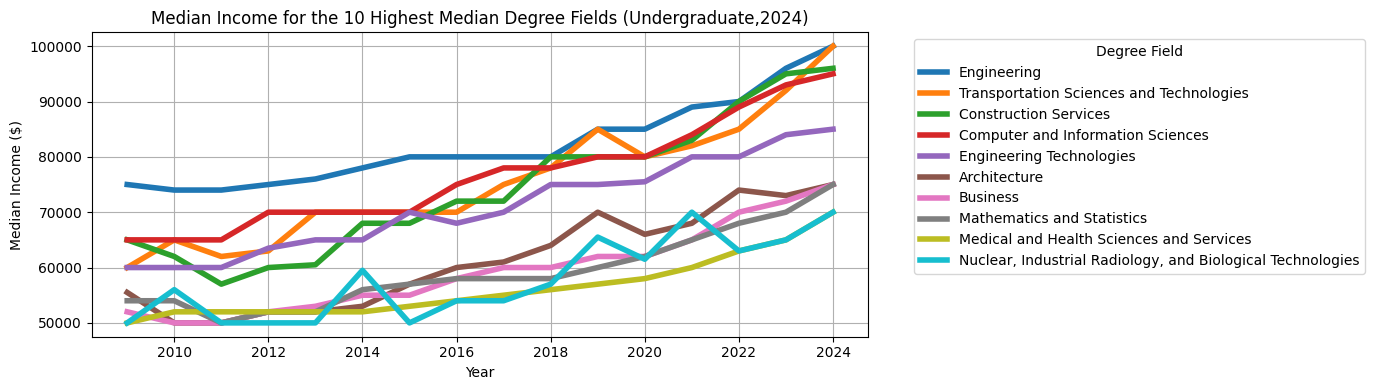

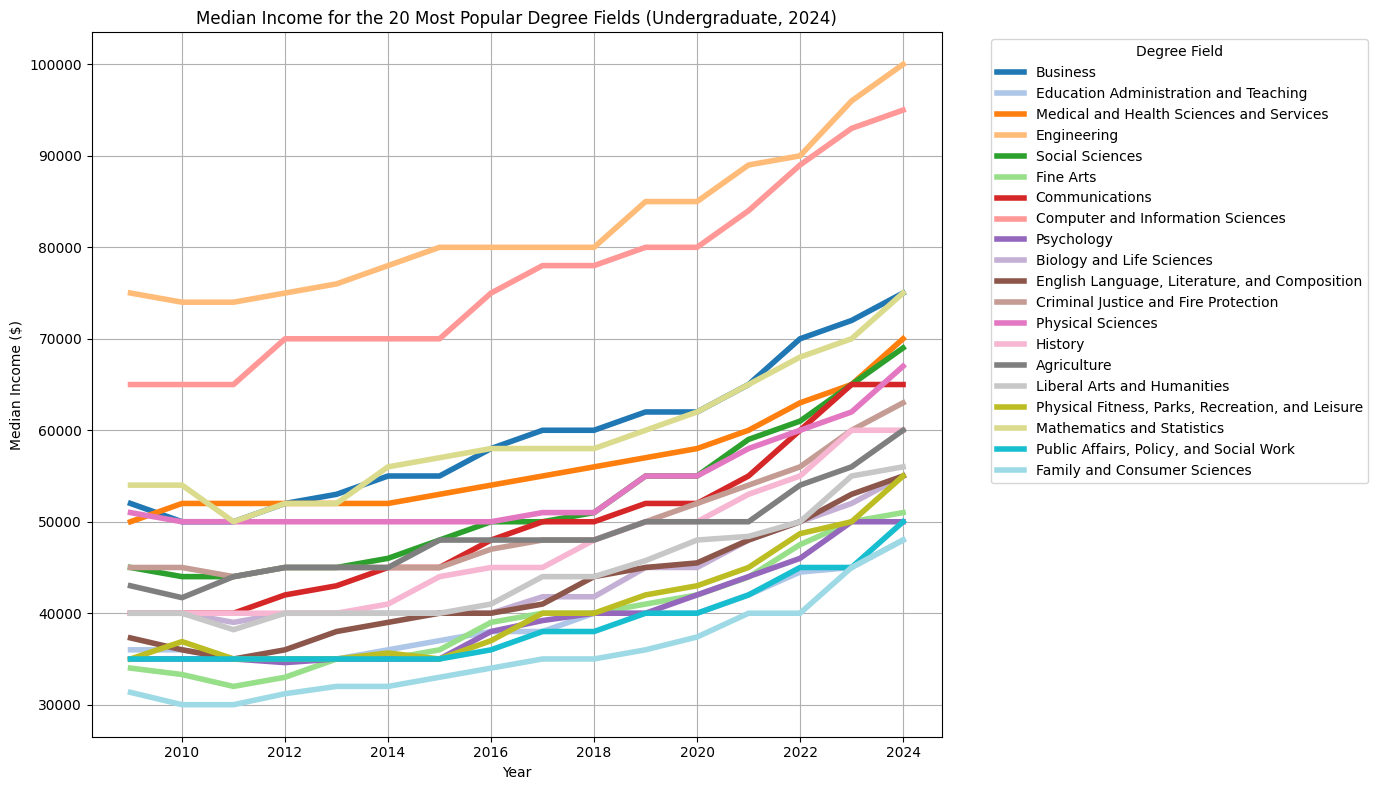

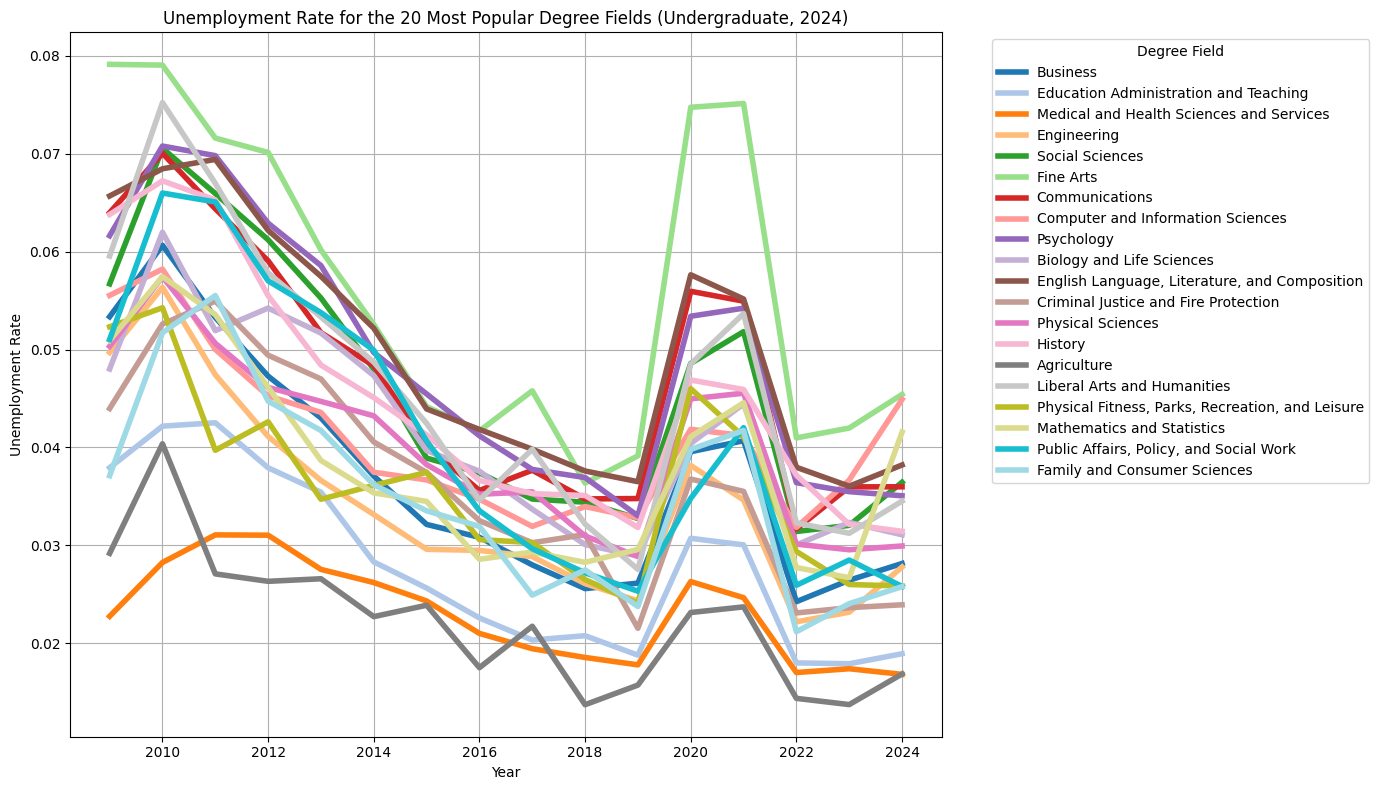

In [5]:
undergrad_grouped = grouped[grouped["undergrad"]]
pivot_median= undergrad_grouped.pivot(index="YEAR", columns="FIELD_NAME", values="median_wage")
pivot_unemployment = undergrad_grouped .pivot(index="YEAR",columns="FIELD_NAME",values="unemployment_rate")
top10_median = ( pivot_median.loc[2024].nlargest(10) .index)
top10_count_median = (undergrad_grouped[undergrad_grouped["YEAR"] == 2024].nlargest(20, "count")["FIELD_NAME"])
top10_count_unemployment = (undergrad_grouped [undergrad_grouped ["YEAR"] == 2024].nlargest(20, "count")["FIELD_NAME"])


plt.figure(figsize=(14,4))
pivot_median[top10_median].plot(ax=plt.gca(),lw = 4)

plt.title("Median Income for the 10 Highest Median Degree Fields (Undergraduate,2024)")
plt.xlabel("Year")
plt.ylabel("Median Income ($)")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.savefig("median_income_highest.png")
plt.show()

plt.figure(figsize=(14,8))
pivot_median[top10_count_median].plot(ax = plt.gca(),lw = 4,cmap='tab20' )
plt.title(f"Median Income for the 20 Most Popular Degree Fields (Undergraduate, 2024)")
plt.xlabel("Year")
plt.ylabel("Median Income ($)")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.savefig("median_income_popular.png")

plt.show()

plt.figure(figsize = (14,8))
pivot_unemployment[top10_count_unemployment].plot(ax = plt.gca(),lw = 4,cmap='tab20' )

plt.title(f"Unemployment Rate for the 20 Most Popular Degree Fields (Undergraduate, 2024)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.savefig("unemployment_rate_popular.png")
plt.show()

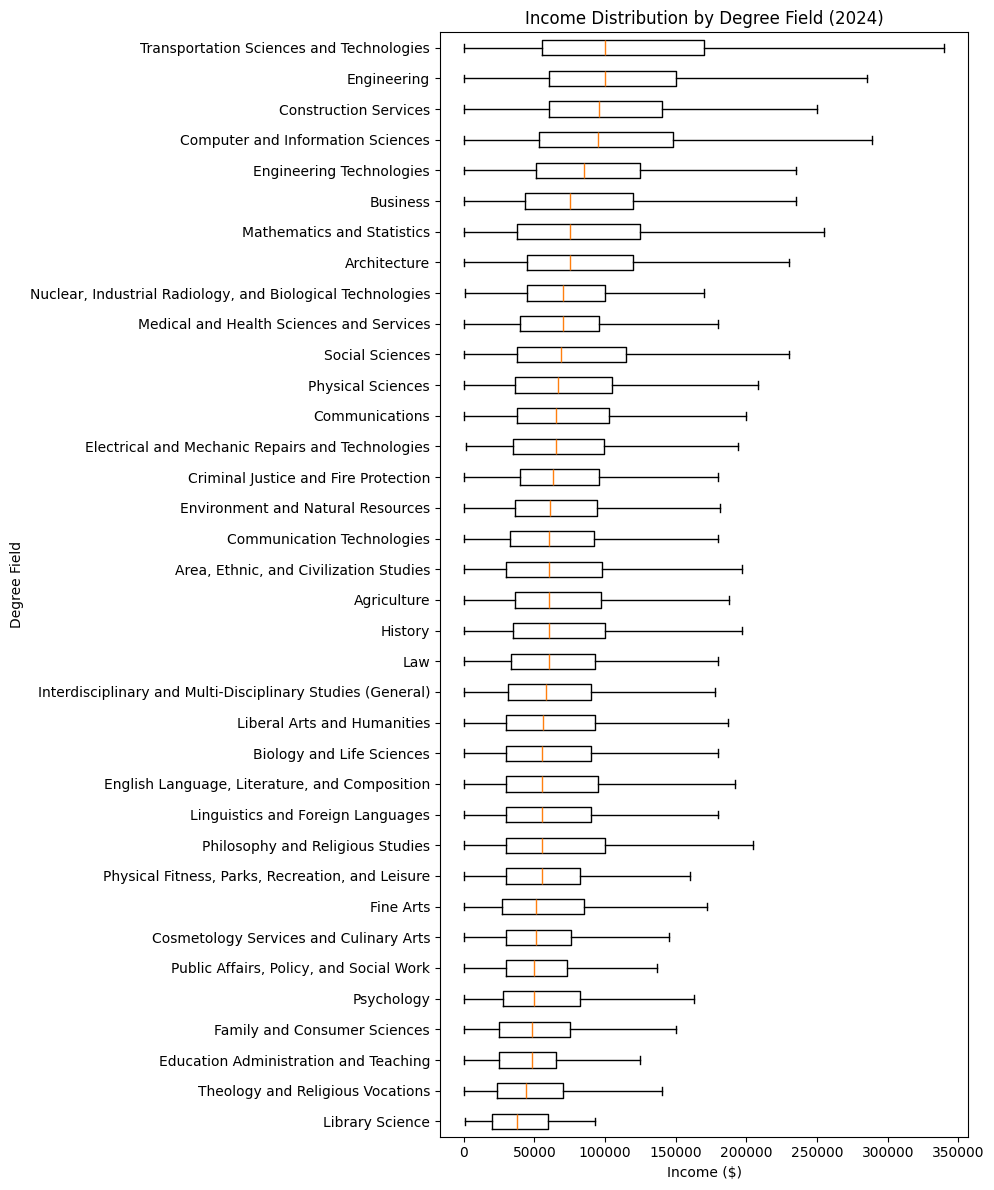

In [6]:
undergrad_2024 = data[ (data["YEAR"] == 2024) & (data["undergrad"] == True) & (data["INCWAGE"]>0)]
order = (undergrad_2024.groupby("FIELD_NAME")["INCWAGE"].median().sort_values().index)
a = [ undergrad_2024.loc[undergrad_2024["FIELD_NAME"] == field, "INCWAGE"] for field in order]

plt.figure(figsize=(10, 12))
plt.boxplot(a,tick_labels=order, vert=False, showfliers=False)
plt.xlabel("Income ($)")
plt.ylabel("Degree Field")
plt.title("Income Distribution by Degree Field (2024)")
plt.tight_layout()
plt.savefig("incomedist.png")
plt.show()

In [7]:
undergrad_grouped_2024 = undergrad_grouped[undergrad_grouped["YEAR"] == 2024][["FIELD_NAME", "median_wage", "unemployment_rate"]]
grad_grouped_2024 = grouped[ (grouped["YEAR"] == 2024) & (~grouped["undergrad"])][["FIELD_NAME", "median_wage", "unemployment_rate"]]
all_grouped_2024 = undergrad_grouped_2024.merge(grad_grouped_2024,on="FIELD_NAME",suffixes=("_undergrad", "_grad"))
all_grouped_2024["absdiff"] = (all_grouped_2024["median_wage_grad"]- all_grouped_2024["median_wage_undergrad"])

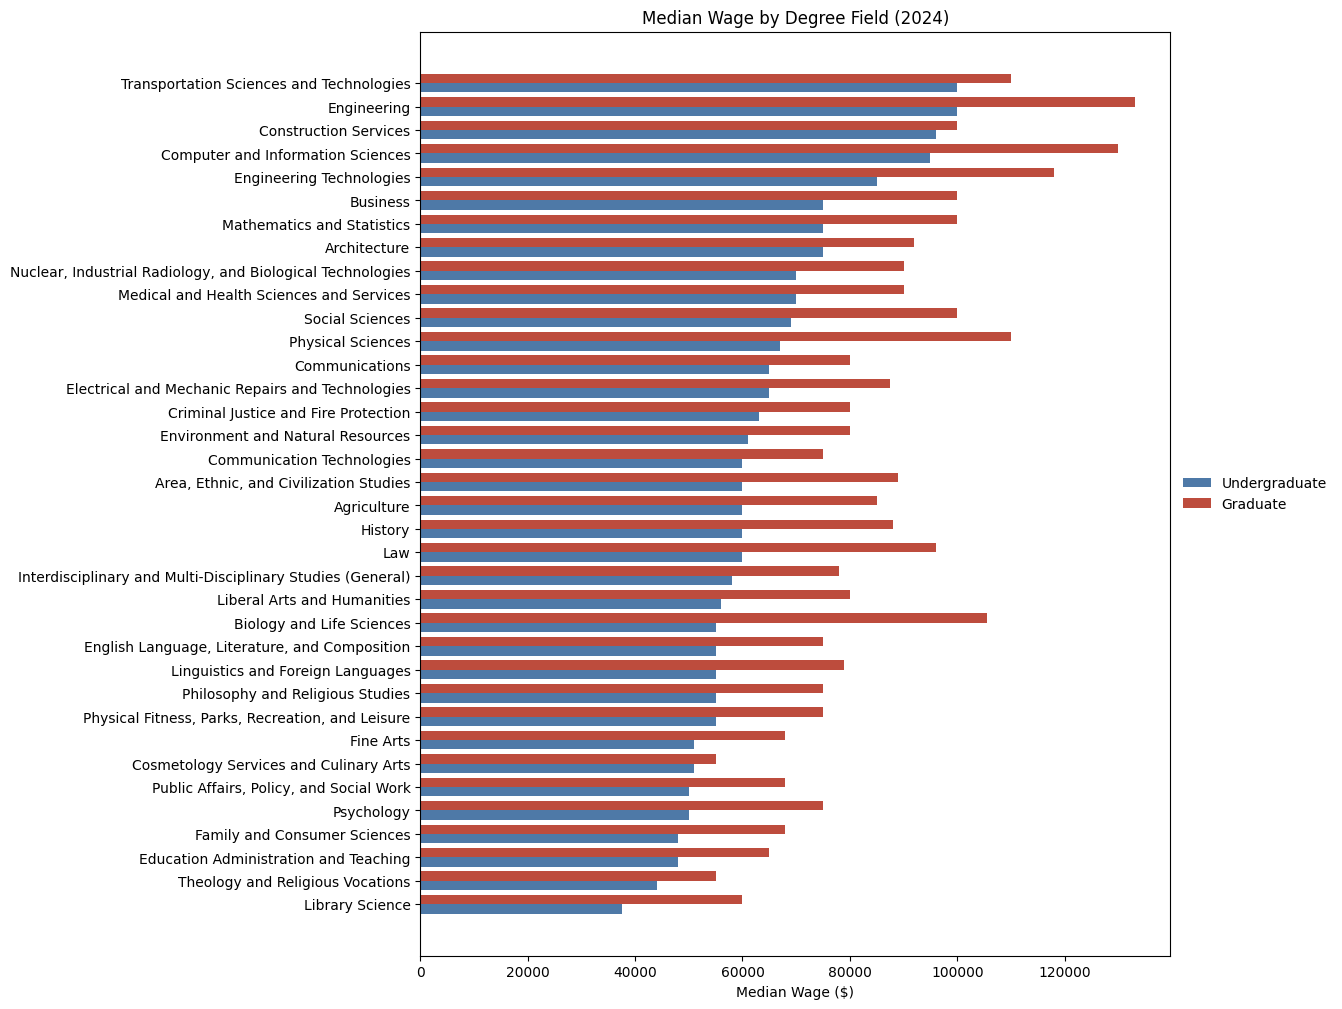

In [8]:
all_grouped_2024 = all_grouped_2024.sort_values("median_wage_undergrad")
y = np.arange(len(all_grouped_2024))
bar_height = 0.4
fig, ax = plt.subplots(figsize=(12, 12))

ax.barh(y - bar_height/2, all_grouped_2024["median_wage_undergrad"],height=bar_height,label="Undergraduate",color="#4E79A7")
ax.barh(y + bar_height/2,all_grouped_2024["median_wage_grad"],height=bar_height,label="Graduate",color="#BD4C3D")

ax.set_yticks(y)
ax.set_yticklabels(all_grouped_2024["FIELD_NAME"])
ax.set_xlabel("Median Wage ($)")
ax.set_title("Median Wage by Degree Field (2024)")

ax.legend(loc="center left",bbox_to_anchor=(1, 0.5),frameon=False)

fig.subplots_adjust(right=0.75)
plt.savefig("median_wage.png", bbox_inches="tight", dpi=300)
plt.show()

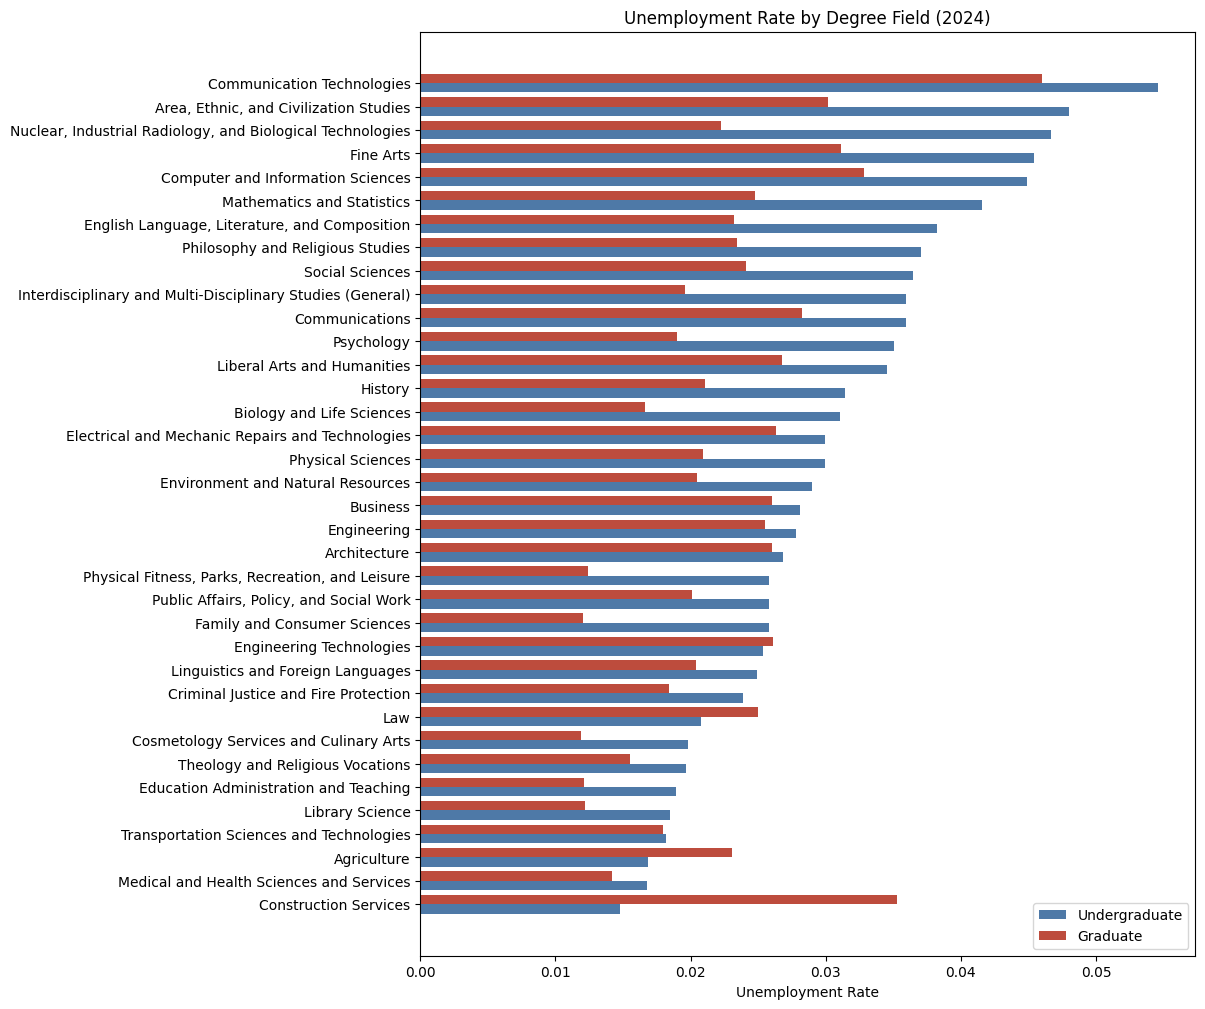

In [9]:
all_grouped_2024 = all_grouped_2024.sort_values("unemployment_rate_undergrad")

y = np.arange(len(all_grouped_2024))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(y - bar_height/2,all_grouped_2024["unemployment_rate_undergrad"],height=bar_height,label="Undergraduate",color="#4E79A7")

ax.barh(y + bar_height/2,all_grouped_2024["unemployment_rate_grad"],height=bar_height,label="Graduate",color="#BD4C3D")

ax.set_yticks(y)
ax.set_yticklabels(all_grouped_2024["FIELD_NAME"])
ax.set_xlabel("Unemployment Rate")
ax.set_title("Unemployment Rate by Degree Field (2024)")

ax.legend()

plt.savefig("unemployment_rate.png", bbox_inches="tight", dpi=300)
plt.show()

In [10]:
B = 3000

results = []

data_2024 = data[(data["YEAR"] == 2024) &(data["INCWAGE"] > 0)]

for field in sorted(data_2024["FIELD_NAME"].unique()):

    ug = data_2024[(data_2024["FIELD_NAME"] == field) &(data_2024["undergrad"]) ]["INCWAGE"]

    grad = data_2024[(data_2024["FIELD_NAME"] == field) &(~data_2024["undergrad"])]["INCWAGE"]

    boot = np.empty(B)

    for i in range(B):
        ug_sample = ug.sample(n=len(ug), replace=True)
        grad_sample = grad.sample(n=len(grad), replace=True)
        boot[i] = grad_sample.median() - ug_sample.median()

    results.append({
        "FIELD_NAME": field,
        "median_difference": grad.median() - ug.median(),
        "ci_lower": np.percentile(boot, 2.5),
        "ci_upper": np.percentile(boot, 97.5)
    })

bootstrap_results = (
    pd.DataFrame(results)
    .sort_values("median_difference", ascending=False)
    .reset_index(drop=True)
)


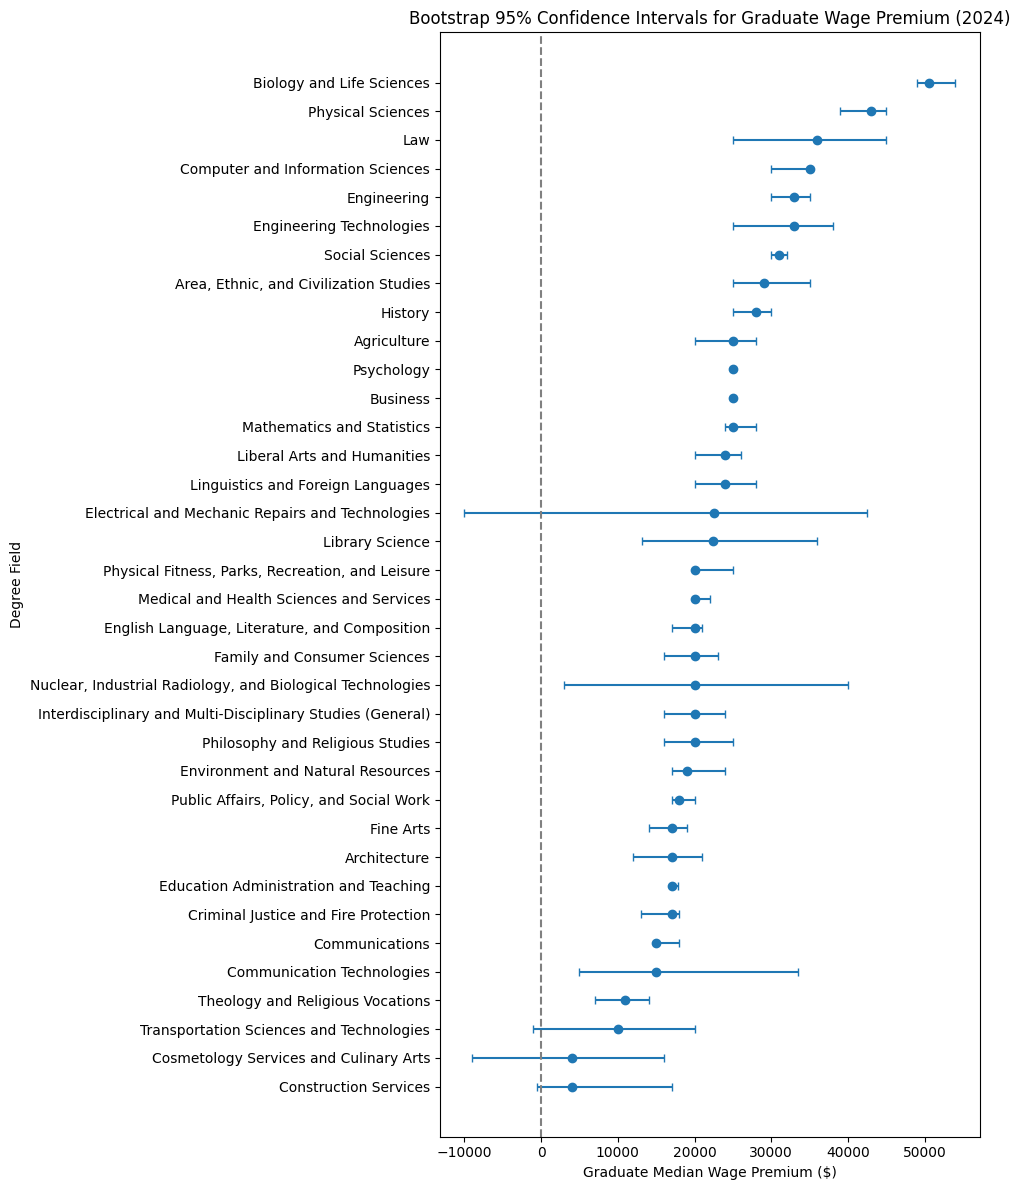

In [11]:
plot_df = bootstrap_results.sort_values("median_difference")

fig, ax = plt.subplots(figsize=(10, 12))

ax.errorbar(plot_df["median_difference"],plot_df["FIELD_NAME"],
    xerr=[
        plot_df["median_difference"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["median_difference"]
    ],
    fmt="o",
    capsize=3
)

ax.axvline(0, color="gray", linestyle="--")

ax.set_xlabel("Graduate Median Wage Premium ($)")
ax.set_ylabel("Degree Field")
ax.set_title("Bootstrap 95% Confidence Intervals for Graduate Wage Premium (2024)")

plt.tight_layout()
plt.savefig("gradpremium.png")
plt.show()

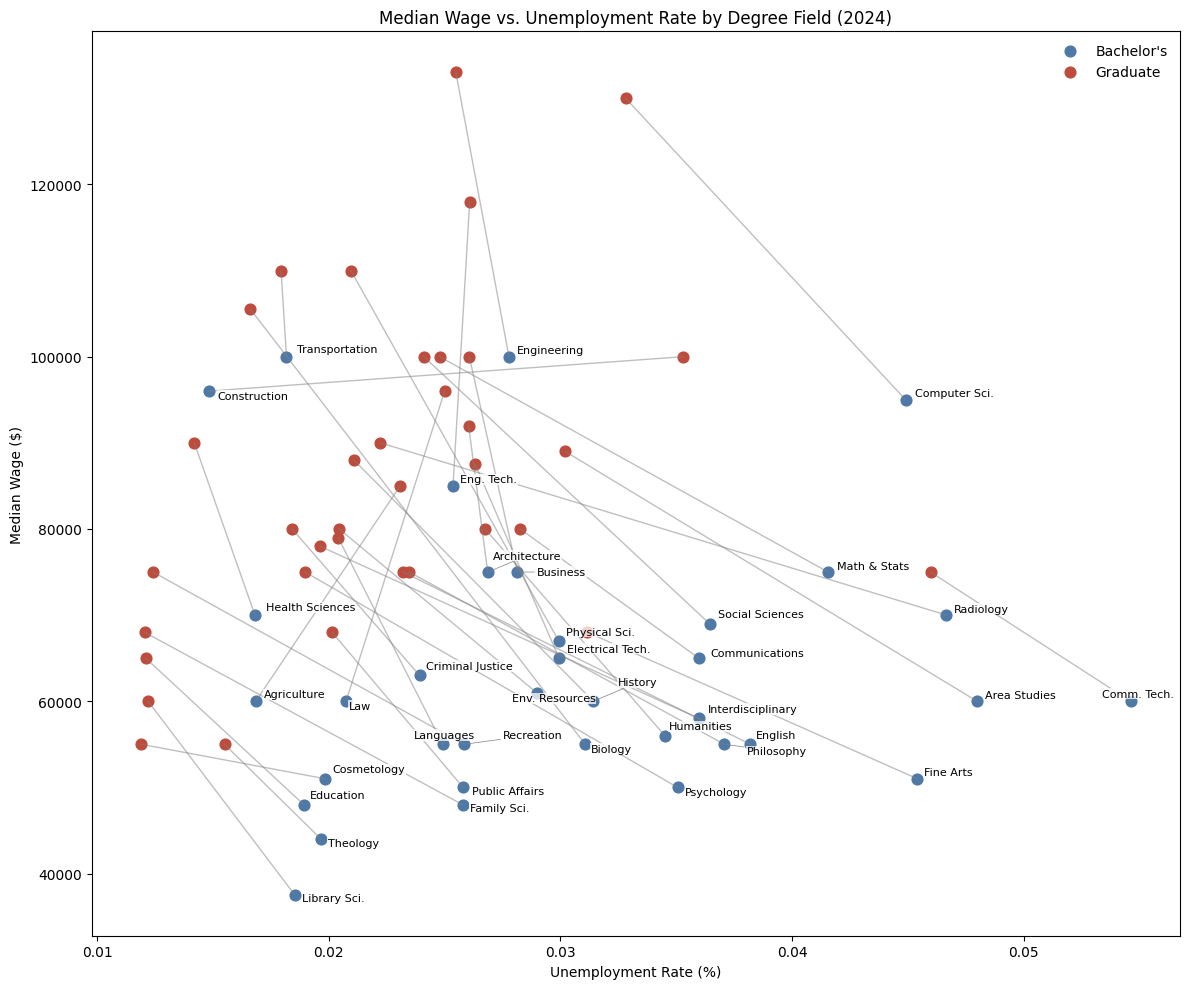

In [12]:
all_grouped_2024_short = all_grouped_2024.copy()
# chatGPT was used to create the short_names map
short_names = {
    "Agriculture": "Agriculture",
    "Environment and Natural Resources": "Env. Resources",
    "Architecture": "Architecture",
    "Area, Ethnic, and Civilization Studies": "Area Studies",
    "Communications": "Communications",
    "Communication Technologies": "Comm. Tech.",
    "Computer and Information Sciences": "Computer Sci.",
    "Cosmetology Services and Culinary Arts": "Cosmetology",
    "Education Administration and Teaching": "Education",
    "Engineering": "Engineering",
    "Engineering Technologies": "Eng. Tech.",
    "Linguistics and Foreign Languages": "Languages",
    "Family and Consumer Sciences": "Family Sci.",
    "Law": "Law",
    "English Language, Literature, and Composition": "English",
    "Liberal Arts and Humanities": "Humanities",
    "Library Science": "Library Sci.",
    "Biology and Life Sciences": "Biology",
    "Mathematics and Statistics": "Math & Stats",
    "Interdisciplinary and Multi-Disciplinary Studies (General)": "Interdisciplinary",
    "Physical Fitness, Parks, Recreation, and Leisure": "Recreation",
    "Philosophy and Religious Studies": "Philosophy",
    "Theology and Religious Vocations": "Theology",
    "Physical Sciences": "Physical Sci.",
    "Nuclear, Industrial Radiology, and Biological Technologies": "Radiology",
    "Psychology": "Psychology",
    "Criminal Justice and Fire Protection": "Criminal Justice",
    "Public Affairs, Policy, and Social Work": "Public Affairs",
    "Social Sciences": "Social Sciences",
    "Construction Services": "Construction",
    "Electrical and Mechanic Repairs and Technologies": "Electrical Tech.",
    "Precision Production and Industrial Arts": "Industrial Arts",
    "Transportation Sciences and Technologies": "Transportation",
    "Fine Arts": "Fine Arts",
    "Medical and Health Sciences and Services": "Health Sciences",
    "Business": "Business",
    "History": "History"
}

all_grouped_2024_short["SHORT_NAME"] = all_grouped_2024_short["FIELD_NAME"].map(short_names)
fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(all_grouped_2024_short["unemployment_rate_undergrad"],all_grouped_2024_short["median_wage_undergrad"],color="#4E79A7",s=60,label="Bachelor's")

ax.scatter(all_grouped_2024_short["unemployment_rate_grad"],all_grouped_2024_short["median_wage_grad"],color="#BD4C3D",s=60,label="Graduate")



texts = []

for _, row in all_grouped_2024_short.iterrows():
    ax.plot(
        [row["unemployment_rate_undergrad"], row["unemployment_rate_grad"]],
        [row["median_wage_undergrad"], row["median_wage_grad"]],
        color="gray",
        alpha=0.5,
        linewidth=1
    )

    texts.append(
        ax.text(
            row["unemployment_rate_undergrad"],
            row["median_wage_undergrad"],
            row["SHORT_NAME"],
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=0.5)
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)
ax.set_xlabel("Unemployment Rate (%)")
ax.set_ylabel("Median Wage ($)")
ax.set_title("Median Wage vs. Unemployment Rate by Degree Field (2024)")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("scatter.png")
plt.show()

In [13]:
B = 3000
results = []

for field, group in data_2024.groupby("FIELD_NAME"):

    men = group.loc[group["SEX"] == 1, "INCWAGE"].to_numpy()
    women = group.loc[group["SEX"] == 2, "INCWAGE"].to_numpy()

    observed = np.median(men) - np.median(women)

    combined = np.concatenate([men, women])
    diffs = np.empty(B)

    n_men = len(men)


    for i in range(B):
        shuffled = np.random.permutation(combined)

        perm_men = shuffled[:n_men]
        perm_women = shuffled[n_men:]

        diffs[i] = (np.median(perm_men) - np.median(perm_women))

    p_value = np.mean(np.abs(diffs) >= abs(observed))
    results.append({
        "FIELD_NAME": field,
        "Difference": observed,
        "p-value": p_value,
    })

results = pd.DataFrame(results)
results = results.sort_values("p-value")




In [14]:
results["FIELD_NAME"] = results["FIELD_NAME"].map(short_names)

latex_table = results.rename(columns={
    "FIELD_NAME": "Field",
    "Difference": "Median Difference",
    "p-value": "Permutation p-value"
})

latex_table["Median Difference"] = (
    latex_table["Median Difference"]
    .round(0)
    .astype(int)
    .astype(str)
)

latex_table["Permutation p-value"] = latex_table["Permutation p-value"].apply(
    lambda x: "0" if x == 0 else f"{x:.4f}"
)

print(
    latex_table.to_latex(
        index=False,
        caption="Permutation test results.",
        label="tab:permutation_results",
        column_format="lrr"
    )
)

\begin{table}
\caption{Permutation test results.}
\label{tab:permutation_results}
\begin{tabular}{lrr}
\toprule
Field & Median Difference & Permutation p-value \\
\midrule
Agriculture & 19000 & 0 \\
Social Sciences & 26000 & 0 \\
Public Affairs & 17000 & 0 \\
Psychology & 15000 & 0 \\
Physical Sci. & 28000 & 0 \\
Recreation & 13000 & 0 \\
Health Sciences & 17000 & 0 \\
Math & Stats & 25000 & 0 \\
Languages & 19000 & 0 \\
Humanities & 17000 & 0 \\
Law & 24000 & 0 \\
Interdisciplinary & 20000 & 0 \\
History & 16000 & 0 \\
Fine Arts & 13000 & 0 \\
Theology & 11000 & 0 \\
Env. Resources & 15000 & 0 \\
Family Sci. & 25000 & 0 \\
Eng. Tech. & 16000 & 0 \\
Architecture & 18000 & 0 \\
Biology & 28000 & 0 \\
Business & 25000 & 0 \\
English & 15000 & 0 \\
Computer Sci. & 20000 & 0 \\
Construction & 28500 & 0 \\
Communications & 10000 & 0 \\
Criminal Justice & 23000 & 0 \\
Education & 11000 & 0 \\
Engineering & 21000 & 0 \\
Cosmetology & 15000 & 0.0003 \\
Comm. Tech. & 15000 & 0.0003 \\
Area Stud

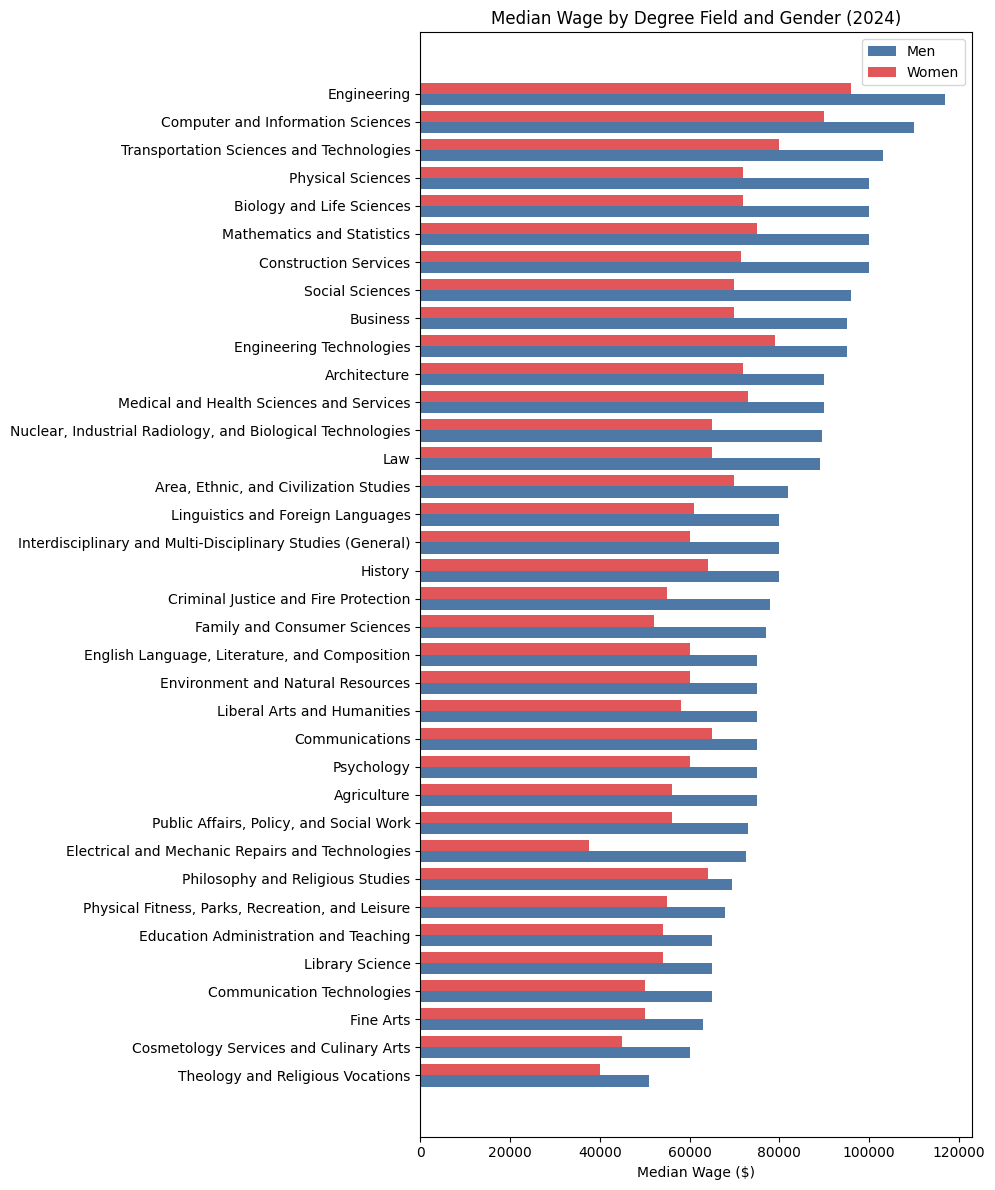

In [15]:
median_gender = (
    data_2024[data_2024["INCWAGE"] > 0]
    .groupby(["FIELD_NAME", "SEX"])["INCWAGE"]
    .median()
    .unstack()
    .rename(columns={1: "Men", 2: "Women"})
    .dropna()
)

median_gender = median_gender.sort_values("Men")

y = np.arange(len(median_gender))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(y - bar_height/2,median_gender["Men"],height=bar_height,label="Men",color="#4E79A7")

ax.barh(y + bar_height/2,median_gender["Women"],height=bar_height,label="Women",color="#E15759")

ax.set_yticks(y)
ax.set_yticklabels(median_gender.index)

ax.set_xlabel("Median Wage ($)")
ax.set_title("Median Wage by Degree Field and Gender (2024)")
ax.legend()

plt.tight_layout()
plt.savefig("sexism.png", dpi=300, bbox_inches="tight")
plt.show()